# Exploratory Data Analysis
## ML-Based Product Recommendation System - Daraz Nepal

**Author:** Binnol Dahal | **Coventry ID:** 14809734  
**Module:** ST6000CEM Individual Project Preparation  
**Module Leader:** Manoj Shrestha


## 0. Setup & Data Loading

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.grid':True,'grid.alpha':0.3,
    'axes.spines.top':False,'axes.spines.right':False,
    'font.family':'sans-serif','axes.titlesize':13,'axes.labelsize':11,
})
ORANGE='#F85606'; BLUE='#2979FF'; GREEN='#00C853'
GOLD='#FFB300';   PURPLE='#9C27B0'
COLORS=[ORANGE,BLUE,GREEN,GOLD,PURPLE,'#00BCD4']

BASE = os.path.join(os.getcwd(),'..','data')
users        = pd.read_csv(os.path.join(BASE,'users.csv'))
products     = pd.read_csv(os.path.join(BASE,'products.csv'))
interactions = pd.read_csv(os.path.join(BASE,'cleaned_interactions.csv'), parse_dates=['timestamp'])
user_feat    = pd.read_csv(os.path.join(BASE,'user_features.csv'))
prod_feat    = pd.read_csv(os.path.join(BASE,'product_features.csv'))

interactions['festival_context'] = interactions['festival_context'].fillna('None').astype(str)
interactions.loc[interactions['festival_context']=='nan','festival_context'] = 'None'

print('Users        :', len(users))
print('Products     :', len(products))
print('Interactions :', len(interactions))
print('Date range   :', interactions['timestamp'].min().date(), 'to', interactions['timestamp'].max().date())


Users        : 10000
Products     : 1000
Interactions : 446028
Date range   : 2024-01-01 to 2024-12-30


## 1. User Demographics

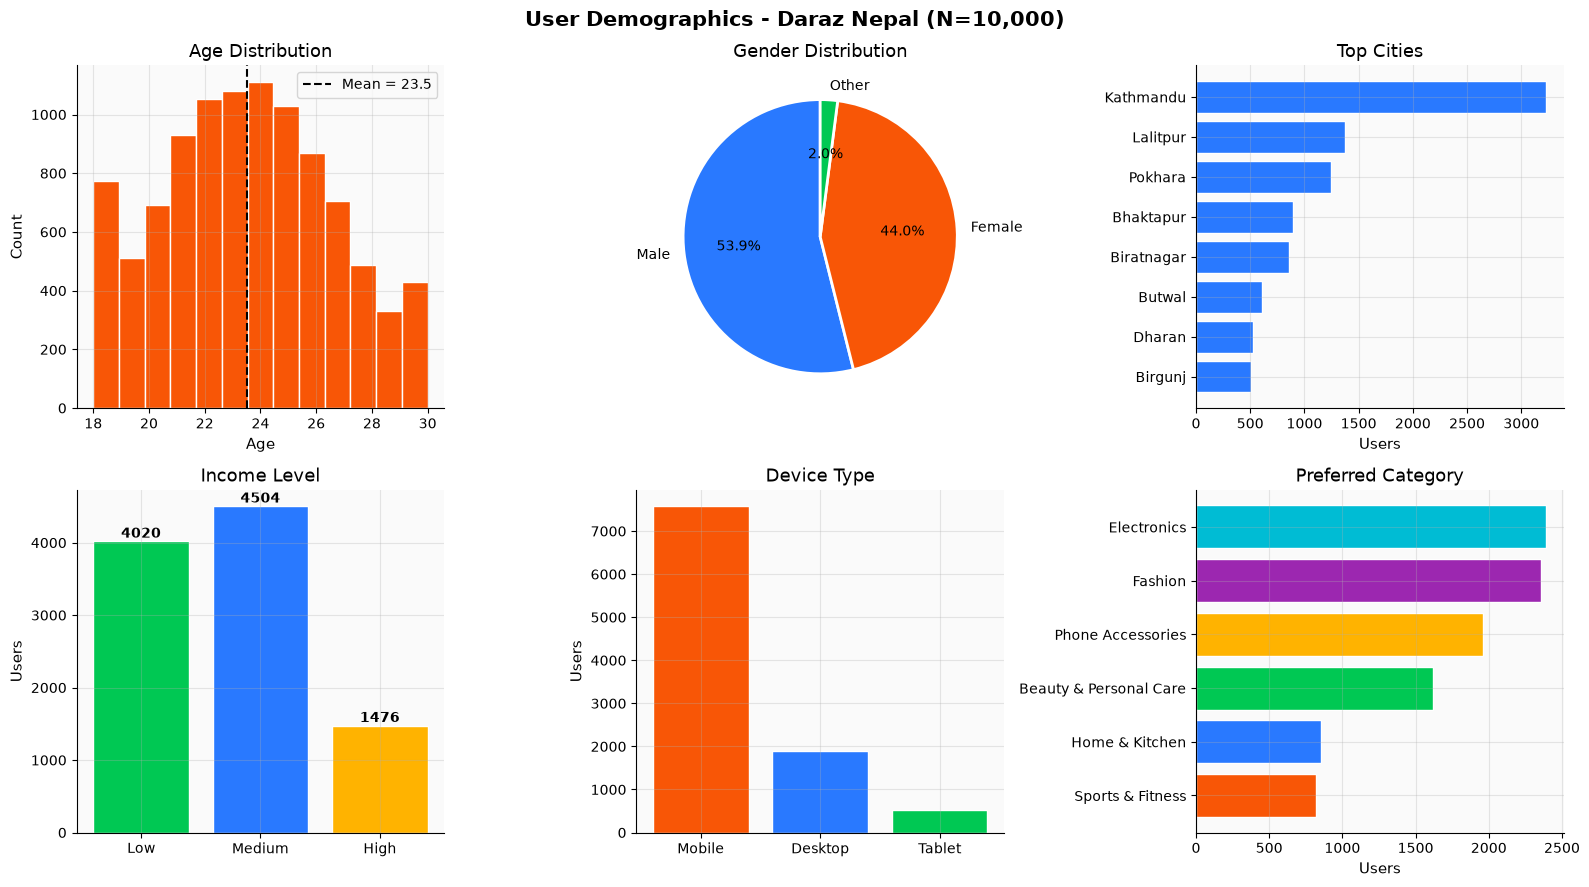

Remittance receivers: 2700 (27.0%)


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('User Demographics - Daraz Nepal (N=10,000)', fontsize=15, fontweight='bold')

ax = axes[0,0]
ax.hist(users['age'], bins=13, color=ORANGE, edgecolor='white')
ax.axvline(users['age'].mean(), color='black', linestyle='--',
           label='Mean = ' + str(round(users['age'].mean(),1)))
ax.set_title('Age Distribution'); ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.legend()

ax = axes[0,1]
gc = users['gender'].value_counts()
ax.pie(gc.values, labels=gc.index, autopct='%1.1f%%',
       colors=[BLUE,ORANGE,GREEN], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Gender Distribution')

ax = axes[0,2]
ct = users['city'].value_counts().head(8)
ax.barh(ct.index[::-1], ct.values[::-1], color=BLUE, edgecolor='white')
ax.set_title('Top Cities'); ax.set_xlabel('Users')

ax = axes[1,0]
inc = users['income_level'].value_counts().reindex(['Low','Medium','High'])
bars = ax.bar(inc.index, inc.values, color=[GREEN,BLUE,GOLD], edgecolor='white')
for b, v in zip(bars, inc.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50, str(v),
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Income Level'); ax.set_ylabel('Users')

ax = axes[1,1]
dv = users['device_type'].value_counts()
ax.bar(dv.index, dv.values, color=[ORANGE,BLUE,GREEN][:len(dv)], edgecolor='white')
ax.set_title('Device Type'); ax.set_ylabel('Users')

ax = axes[1,2]
pc = users['preferred_category'].value_counts()
ax.barh(pc.index[::-1], pc.values[::-1], color=COLORS[:len(pc)], edgecolor='white')
ax.set_title('Preferred Category'); ax.set_xlabel('Users')

plt.tight_layout()
plt.savefig('user_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Remittance receivers:', users['remittance_receiver'].sum(),
      '(' + str(round(users['remittance_receiver'].mean()*100,1)) + '%)')


## 2. Product Catalog Analysis

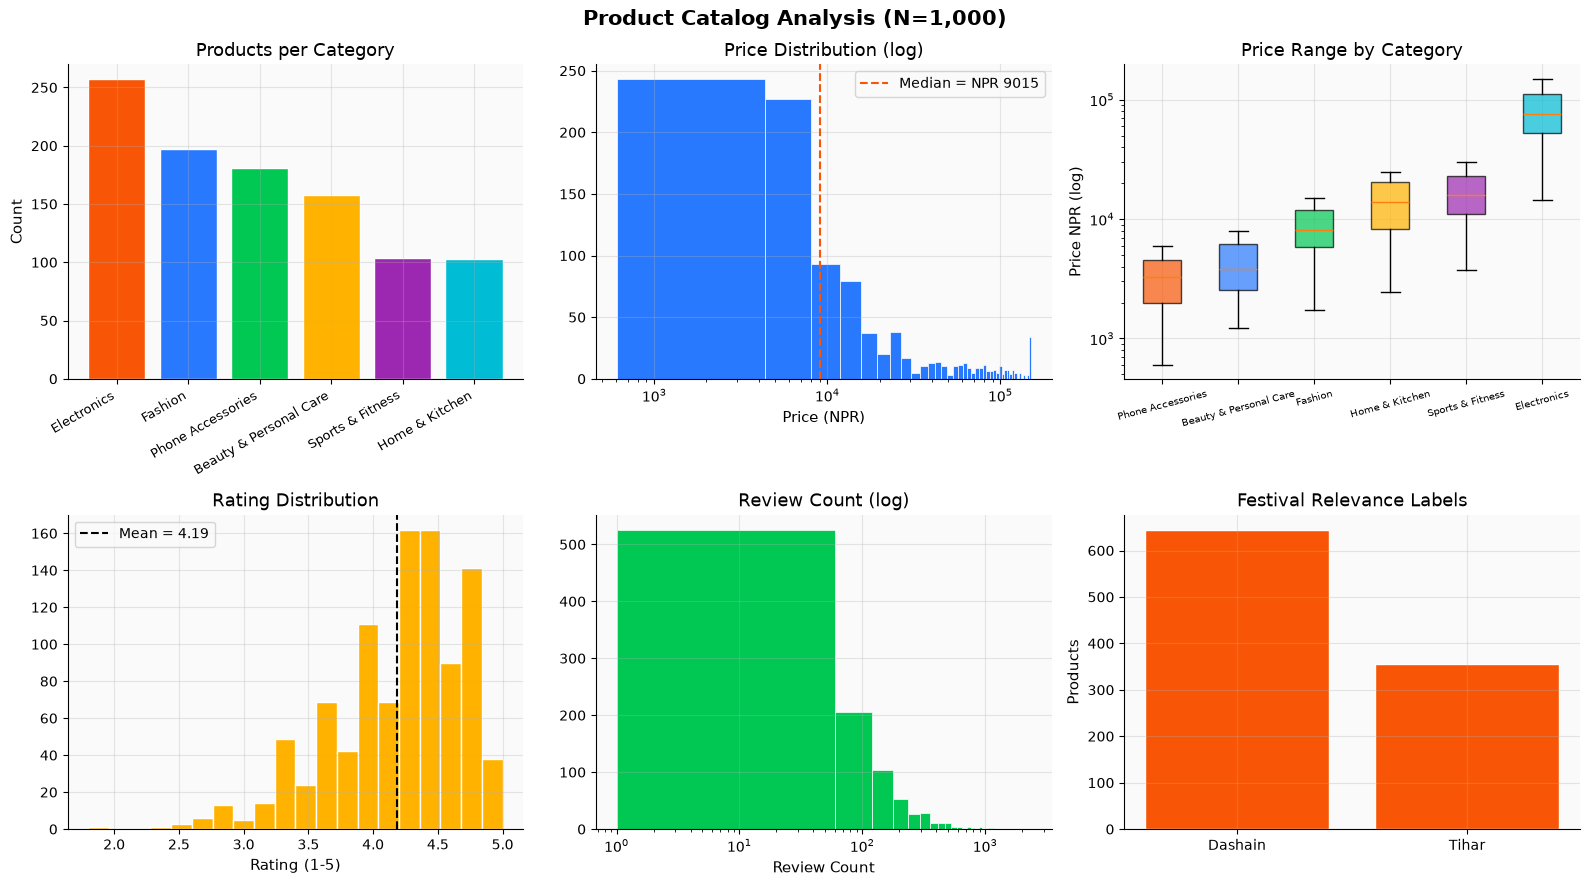

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Product Catalog Analysis (N=1,000)', fontsize=15, fontweight='bold')

ax = axes[0,0]
cc = products['category'].value_counts()
ax.bar(cc.index, cc.values, color=COLORS, edgecolor='white')
ax.set_xticklabels(cc.index, rotation=30, ha='right', fontsize=9)
ax.set_title('Products per Category'); ax.set_ylabel('Count')

ax = axes[0,1]
ax.hist(products['price_npr'], bins=40, color=BLUE, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
med_price = products['price_npr'].median()
ax.axvline(med_price, color=ORANGE, linestyle='--',
           label='Median = NPR ' + str(int(med_price)))
ax.set_title('Price Distribution (log)'); ax.set_xlabel('Price (NPR)'); ax.legend()

ax = axes[0,2]
cat_order  = products.groupby('category')['price_npr'].median().sort_values().index
data_bp    = [products[products['category']==c]['price_npr'].values for c in cat_order]
tick_lbls  = [c.replace(' & ', ' & ') for c in cat_order]
bp = ax.boxplot(data_bp, tick_labels=tick_lbls, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_yscale('log'); ax.set_title('Price Range by Category')
ax.set_ylabel('Price NPR (log)'); ax.tick_params(axis='x', labelsize=7, rotation=15)

ax = axes[1,0]
ax.hist(products['rating'], bins=20, color=GOLD, edgecolor='white')
ax.axvline(products['rating'].mean(), color='black', linestyle='--',
           label='Mean = ' + str(round(products['rating'].mean(),2)))
ax.set_title('Rating Distribution'); ax.set_xlabel('Rating (1-5)'); ax.legend()

ax = axes[1,1]
ax.hist(products['review_count'], bins=40, color=GREEN, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
ax.set_title('Review Count (log)'); ax.set_xlabel('Review Count')

ax = axes[1,2]
fc = products['festival_relevance'].value_counts()
colors_f = [ORANGE if f != 'None' else '#CCC' for f in fc.index]
ax.bar(fc.index, fc.values, color=colors_f, edgecolor='white')
ax.set_title('Festival Relevance Labels'); ax.set_ylabel('Products')

plt.tight_layout()
plt.savefig('product_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Interaction Patterns

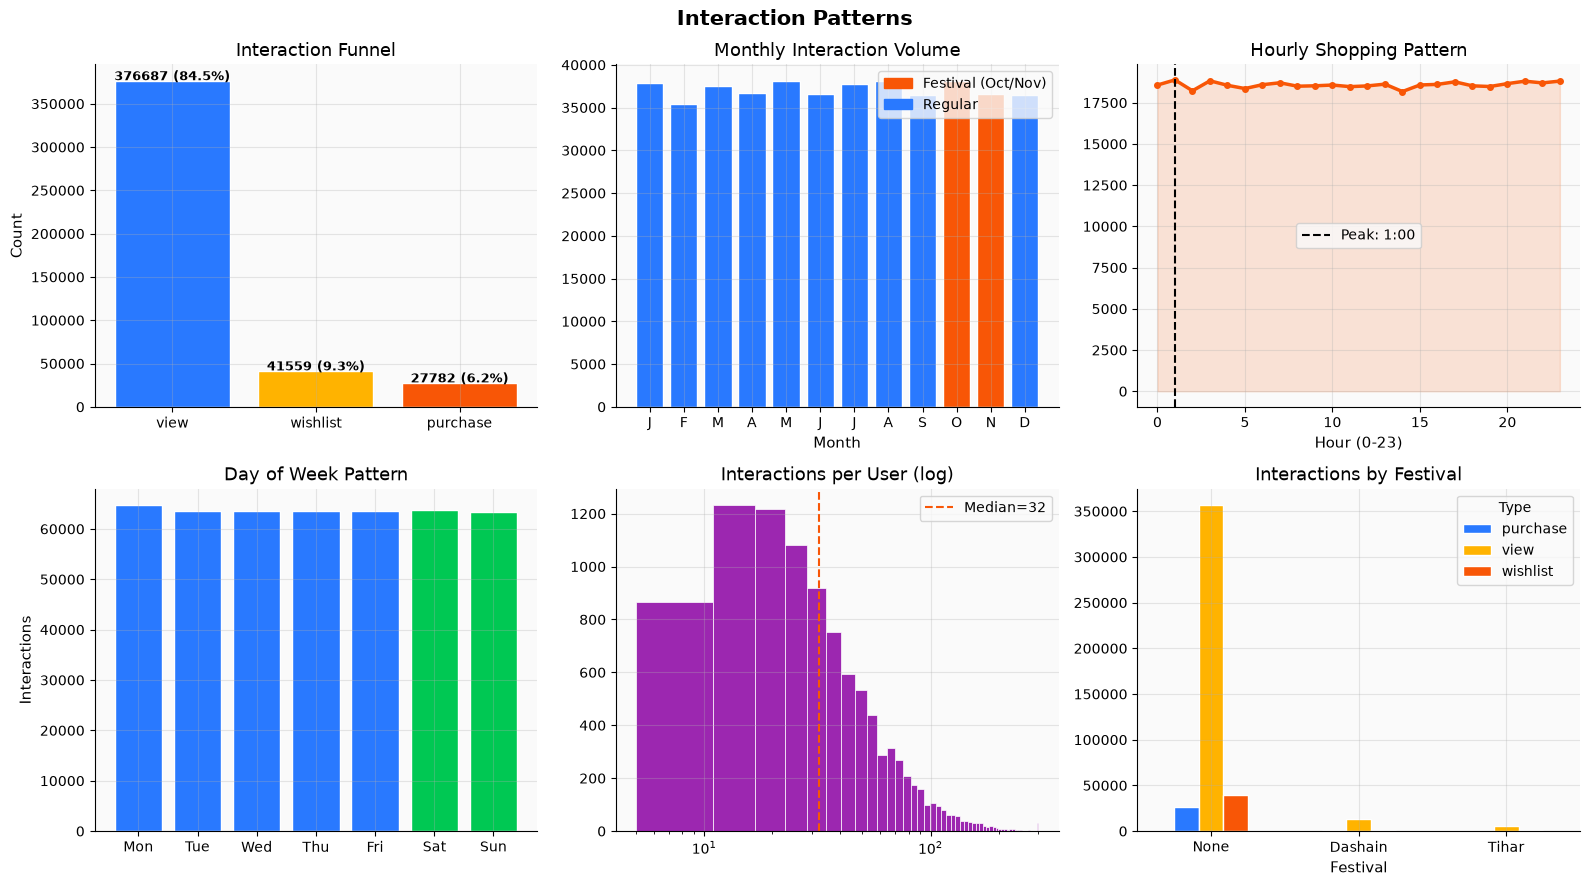

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Interaction Patterns', fontsize=15, fontweight='bold')

ax = axes[0,0]
ic = interactions['interaction_type'].value_counts()
total = len(interactions)
bars = ax.bar(ic.index, ic.values, color=[BLUE,GOLD,ORANGE], edgecolor='white')
for b, v in zip(bars, ic.values):
    pct = str(round(v/total*100,1)) + '%'
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+500,
            str(v) + ' (' + pct + ')', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Interaction Funnel'); ax.set_ylabel('Count')

ax = axes[0,1]
monthly = interactions.groupby('month').size()
bar_c = [ORANGE if m in [10,11] else BLUE for m in monthly.index]
ax.bar(monthly.index, monthly.values, color=bar_c, edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('Monthly Interaction Volume'); ax.set_xlabel('Month')
o_patch = mpatches.Patch(color=ORANGE, label='Festival (Oct/Nov)')
b_patch = mpatches.Patch(color=BLUE,   label='Regular')
ax.legend(handles=[o_patch, b_patch])

ax = axes[0,2]
hourly = interactions.groupby('hour').size()
ax.plot(hourly.index, hourly.values, color=ORANGE, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color=ORANGE)
peak = hourly.idxmax()
ax.axvline(peak, color='black', linestyle='--', label='Peak: ' + str(peak) + ':00')
ax.set_title('Hourly Shopping Pattern'); ax.set_xlabel('Hour (0-23)'); ax.legend()

ax = axes[1,0]
dow  = interactions.groupby('dayofweek').size()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
bar_cd = [GREEN if d >= 5 else BLUE for d in dow.index]
ax.bar([days[d] for d in dow.index], dow.values, color=bar_cd, edgecolor='white')
ax.set_title('Day of Week Pattern'); ax.set_ylabel('Interactions')

ax = axes[1,1]
uic = interactions.groupby('user_id').size()
ax.hist(uic.values, bins=50, color=PURPLE, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
ax.axvline(uic.median(), color=ORANGE, linestyle='--',
           label='Median=' + str(int(uic.median())))
ax.set_title('Interactions per User (log)'); ax.legend()

ax = axes[1,2]
fg = interactions.groupby(['festival_context','interaction_type']).size().unstack(fill_value=0)
fg = fg.reindex(['None','Dashain','Tihar'])
fg.plot(kind='bar', ax=ax, color=[BLUE,GOLD,ORANGE], edgecolor='white', rot=0)
ax.set_title('Interactions by Festival'); ax.set_xlabel('Festival'); ax.legend(title='Type')

plt.tight_layout()
plt.savefig('interaction_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. RFM Customer Segmentation

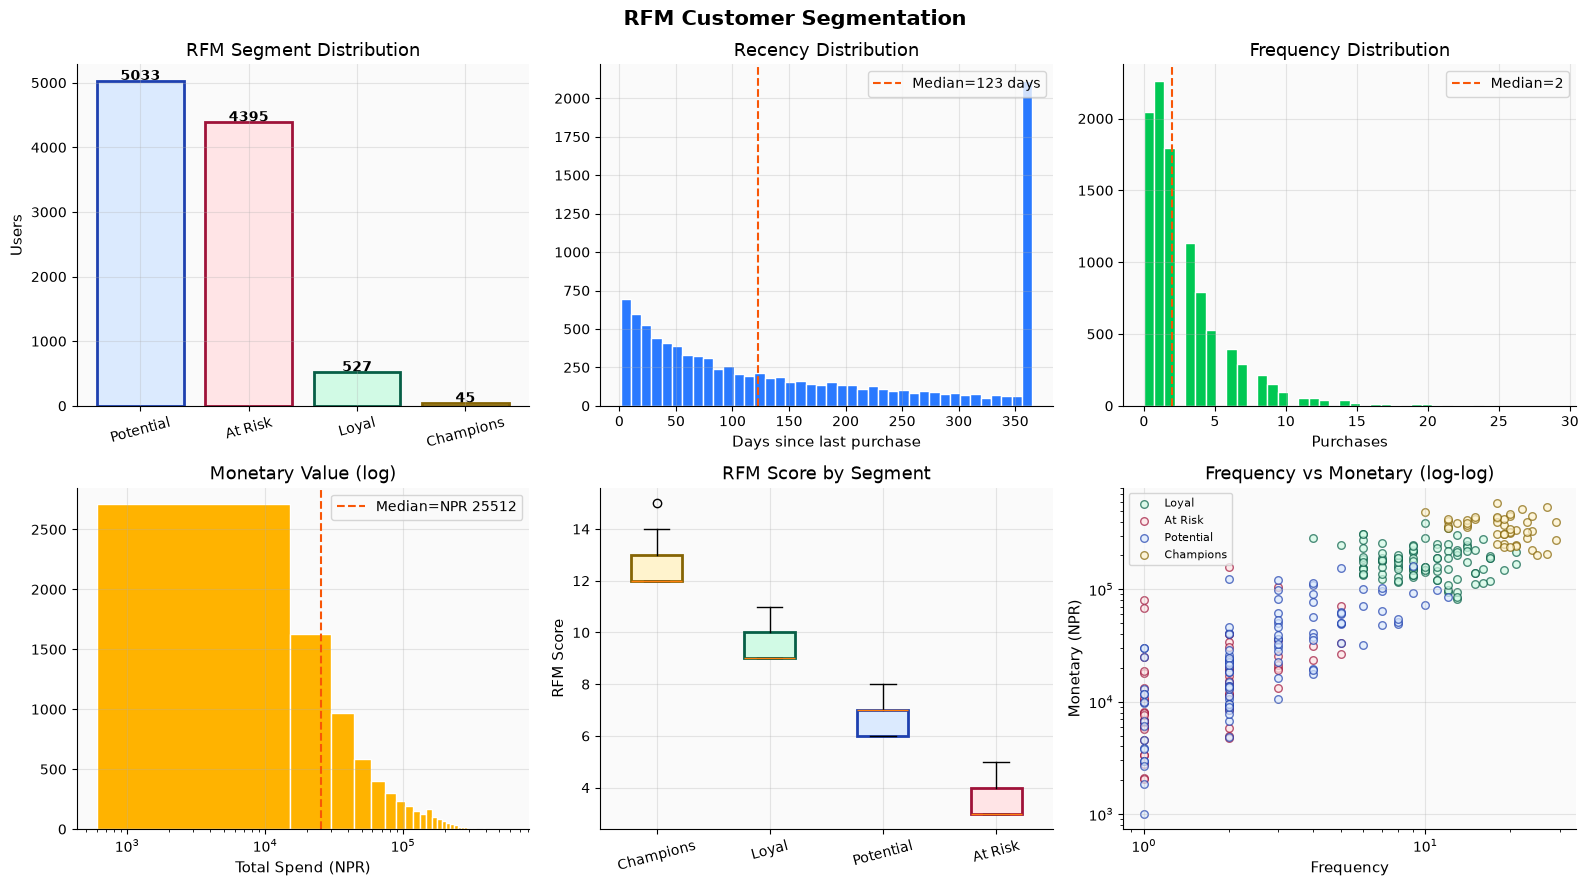

           frequency   monetary  RFM_score
segment                                   
At Risk         0.89   10876.10       3.66
Champions      19.16  360900.16      12.49
Loyal          10.36  182603.35       9.47
Potential       3.49   45289.15       6.87


In [13]:
seg_colors = {'Champions':'#856404','Loyal':'#065F46',
              'Potential':'#1E40AF','At Risk':'#9F1239','Lost':'#6B7280'}
seg_bg     = {'Champions':'#FFF3CD','Loyal':'#D1FAE5',
              'Potential':'#DBEAFE','At Risk':'#FFE4E6','Lost':'#F3F4F6'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold')

ax = axes[0,0]
if 'segment' in user_feat.columns:
    sc = user_feat['segment'].value_counts()
    colors_s = [seg_bg.get(s,'#EEE') for s in sc.index]
    edge_s   = [seg_colors.get(s,'#999') for s in sc.index]
    bars = ax.bar(sc.index, sc.values, color=colors_s, edgecolor=edge_s, linewidth=2)
    for b, v in zip(bars, sc.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
                str(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_title('RFM Segment Distribution'); ax.set_ylabel('Users')
    ax.set_xticklabels(sc.index, rotation=15)

ax = axes[0,1]
if 'recency' in user_feat.columns:
    ax.hist(user_feat['recency'].clip(upper=365), bins=40, color=BLUE, edgecolor='white')
    ax.axvline(user_feat['recency'].median(), color=ORANGE, linestyle='--',
               label='Median=' + str(int(user_feat['recency'].median())) + ' days')
    ax.set_title('Recency Distribution'); ax.set_xlabel('Days since last purchase'); ax.legend()

ax = axes[0,2]
if 'frequency' in user_feat.columns:
    ax.hist(user_feat['frequency'].clip(upper=100), bins=40, color=GREEN, edgecolor='white')
    ax.axvline(user_feat['frequency'].median(), color=ORANGE, linestyle='--',
               label='Median=' + str(int(user_feat['frequency'].median())))
    ax.set_title('Frequency Distribution'); ax.set_xlabel('Purchases'); ax.legend()

ax = axes[1,0]
if 'monetary' in user_feat.columns:
    mon = user_feat[user_feat['monetary']>0]['monetary']
    ax.hist(mon, bins=40, color=GOLD, edgecolor='white')
    ax.set_xscale('log')
    ax.axvline(mon.median(), color=ORANGE, linestyle='--',
               label='Median=NPR ' + str(int(mon.median())))
    ax.set_title('Monetary Value (log)'); ax.set_xlabel('Total Spend (NPR)'); ax.legend()

ax = axes[1,1]
if all(c in user_feat.columns for c in ['segment','RFM_score']):
    seg_order = [s for s in ['Champions','Loyal','Potential','At Risk','Lost']
                 if s in user_feat['segment'].unique()]
    rfm_data  = [user_feat[user_feat['segment']==s]['RFM_score'].values for s in seg_order]
    bp = ax.boxplot(rfm_data, tick_labels=seg_order, patch_artist=True)
    for patch, seg in zip(bp['boxes'], seg_order):
        patch.set_facecolor(seg_bg.get(seg,'#EEE'))
        patch.set_edgecolor(seg_colors.get(seg,'#999'))
        patch.set_linewidth(2)
    ax.set_title('RFM Score by Segment'); ax.set_ylabel('RFM Score')
    ax.set_xticklabels(seg_order, rotation=15)

ax = axes[1,2]
if all(c in user_feat.columns for c in ['frequency','monetary','segment']):
    for seg in user_feat['segment'].unique():
        sub = user_feat[user_feat['segment']==seg]
        n   = min(100, len(sub))
        sub = sub.sample(n, random_state=42)
        ax.scatter(sub['frequency'], sub['monetary'],
                   color=seg_bg.get(seg,'#EEE'),
                   edgecolors=seg_colors.get(seg,'#999'),
                   alpha=0.7, s=30, label=seg, linewidths=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title('Frequency vs Monetary (log-log)')
    ax.set_xlabel('Frequency'); ax.set_ylabel('Monetary (NPR)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

if 'segment' in user_feat.columns:
    print(user_feat.groupby('segment')[['frequency','monetary','RFM_score']].mean().round(2))


## 5. Nepal Festival Shopping Analysis

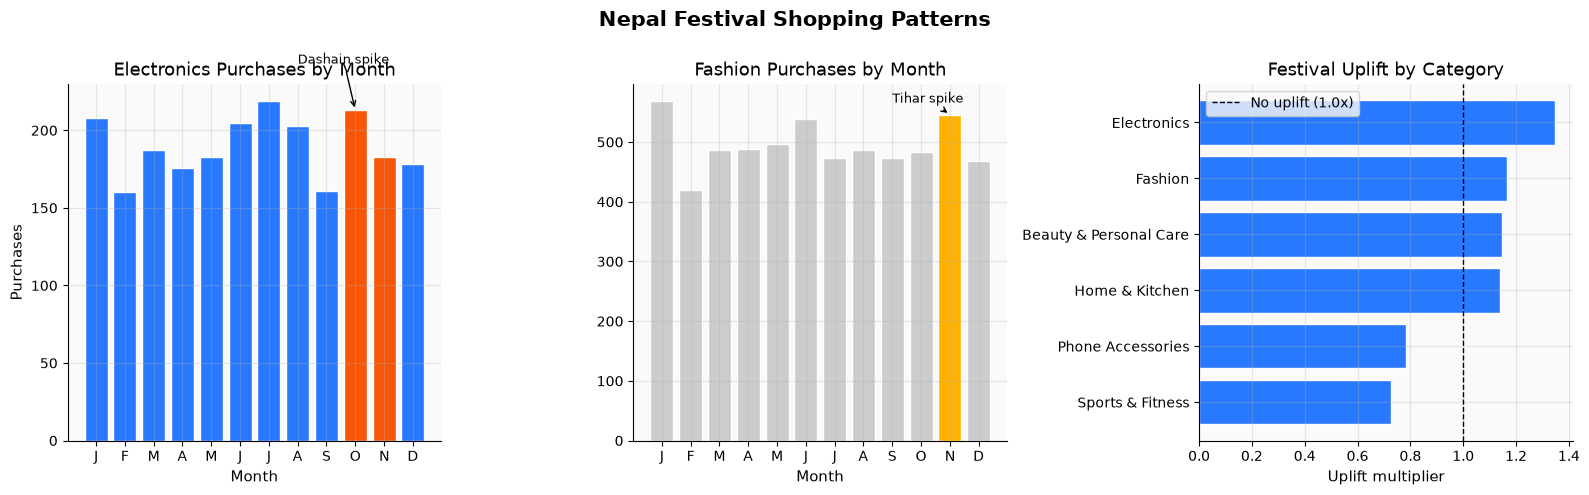

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nepal Festival Shopping Patterns', fontsize=15, fontweight='bold')

ax = axes[0]
ep  = products[products['category']=='Electronics']['product_id']
ei  = interactions[interactions['product_id'].isin(ep) &
                   (interactions['interaction_type']=='purchase')]
em  = ei.groupby('month').size()
col = [ORANGE if m in [10,11] else BLUE for m in em.index]
ax.bar(em.index, em.values, color=col, edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('Electronics Purchases by Month')
ax.set_xlabel('Month'); ax.set_ylabel('Purchases')
if 10 in em.index:
    ax.annotate('Dashain spike', xy=(10, em[10]),
                xytext=(8, em[10]+30),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax = axes[1]
fp  = products[products['category']=='Fashion']['product_id']
fi  = interactions[interactions['product_id'].isin(fp) &
                   (interactions['interaction_type']=='purchase')]
fm  = fi.groupby('month').size()
col2= ['#FFB300' if m==11 else '#CCC' for m in fm.index]
ax.bar(fm.index, fm.values, color=col2, edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('Fashion Purchases by Month'); ax.set_xlabel('Month')
if 11 in fm.index:
    ax.annotate('Tihar spike', xy=(11, fm[11]),
                xytext=(9, fm[11]+20),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax = axes[2]
uplifts = []
for cat in products['category'].unique():
    cp = products[products['category']==cat]['product_id']
    ci = interactions[interactions['product_id'].isin(cp)]
    f  = ci[ci['festival_context']!='None']
    nf = ci[ci['festival_context']=='None']
    up = (len(f)/18) / max(len(nf)/347, 1)
    uplifts.append({'category':cat,'uplift':up})
ud = pd.DataFrame(uplifts).sort_values('uplift')
ax.barh(ud['category'], ud['uplift'],
        color=[ORANGE if u>1.5 else BLUE for u in ud['uplift']], edgecolor='white')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='No uplift (1.0x)')
ax.set_title('Festival Uplift by Category')
ax.set_xlabel('Uplift multiplier'); ax.legend()

plt.tight_layout()
plt.savefig('festival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. User-Item Matrix Sparsity

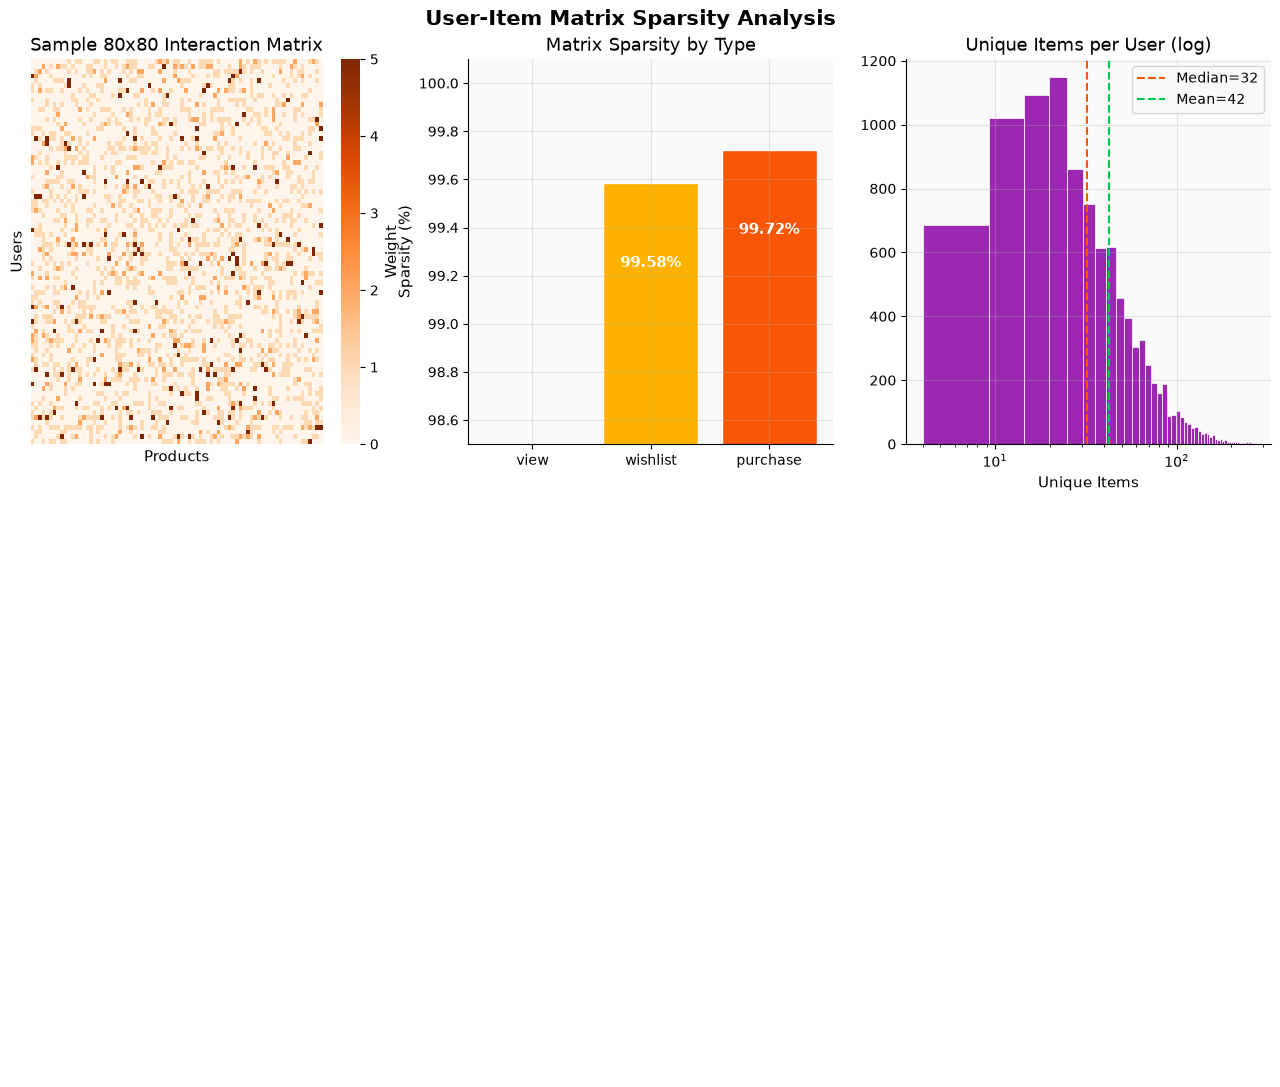

Overall matrix sparsity: 95.75%
Mean items per user    : 42.5
Median items per user  : 32


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('User-Item Matrix Sparsity Analysis', fontsize=15, fontweight='bold')

weight_map = {'view':1,'wishlist':2,'purchase':5}
interactions['w'] = interactions['interaction_type'].map(weight_map)

su  = interactions['user_id'].value_counts().head(80).index
si  = interactions['product_id'].value_counts().head(80).index
sub = interactions[interactions['user_id'].isin(su) & interactions['product_id'].isin(si)]
mat = sub.groupby(['user_id','product_id'])['w'].max().unstack(fill_value=0)

ax = axes[0]
sns.heatmap(mat.values, ax=ax, cmap='Oranges',
            cbar_kws={'label':'Weight'}, xticklabels=False, yticklabels=False)
ax.set_title('Sample 80x80 Interaction Matrix')
ax.set_xlabel('Products'); ax.set_ylabel('Users')

ax = axes[1]
total_cells = 10000 * 1000
filled = {
    'view':     int((interactions['interaction_type']=='view').sum()),
    'wishlist': int((interactions['interaction_type']=='wishlist').sum()),
    'purchase': int((interactions['interaction_type']=='purchase').sum()),
}
sparsity = {k: 1-v/total_cells for k,v in filled.items()}
bars = ax.bar(list(sparsity.keys()), [v*100 for v in sparsity.values()],
              color=[BLUE,GOLD,ORANGE], edgecolor='white')
for b, v in zip(bars, sparsity.values()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()-0.3,
            str(round(v*100,2))+'%', ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')
ax.set_ylim(98.5, 100.1)
ax.set_title('Matrix Sparsity by Type'); ax.set_ylabel('Sparsity (%)')

ax = axes[2]
ipu = interactions.groupby('user_id')['product_id'].nunique()
ax.hist(ipu.values, bins=50, color=PURPLE, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
ax.axvline(ipu.median(), color=ORANGE, linestyle='--',
           label='Median=' + str(int(ipu.median())))
ax.axvline(ipu.mean(), color=GREEN, linestyle='--',
           label='Mean=' + str(int(ipu.mean())))
ax.set_title('Unique Items per User (log)')
ax.set_xlabel('Unique Items'); ax.legend()

plt.tight_layout()
plt.savefig('sparsity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

overall = 1 - len(interactions.groupby(['user_id','product_id']).size()) / total_cells
print('Overall matrix sparsity:', str(round(overall*100,2))+'%')
print('Mean items per user    :', round(ipu.mean(),1))
print('Median items per user  :', int(ipu.median()))


## 7. SHAP Feature Importance

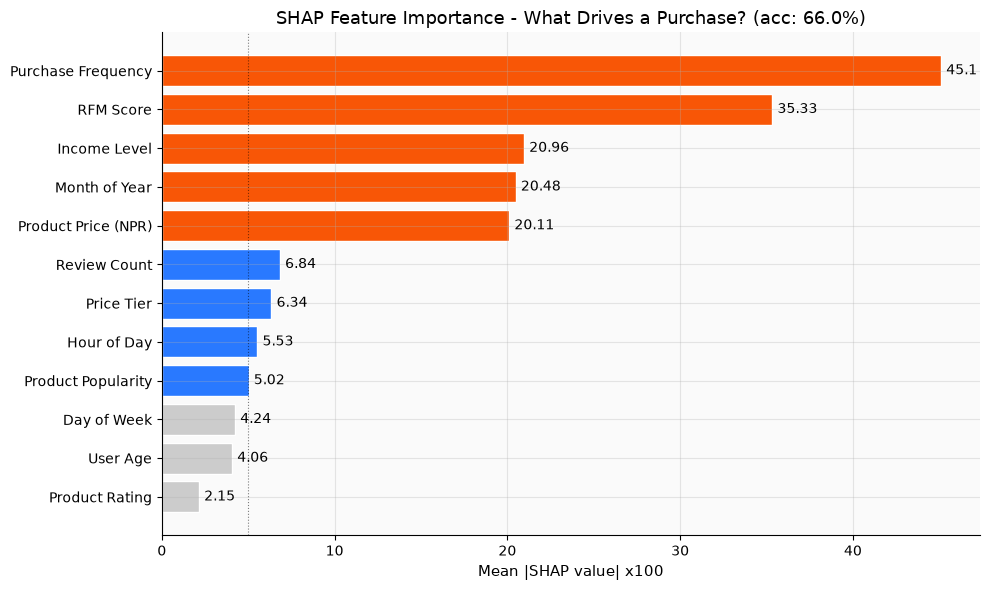

Top 5 features:
1. Purchase Frequency -- SHAP=0.451
2. RFM Score -- SHAP=0.3533
3. Income Level -- SHAP=0.2096
4. Month of Year -- SHAP=0.2048
5. Product Price (NPR) -- SHAP=0.2011


In [16]:
shap_path = os.path.join(os.getcwd(),'..','data','shap_results.json')
with open(shap_path) as f:
    shap_data = json.load(f)

labels = shap_data['feature_labels'][:12]
values = shap_data['shap_values'][:12]

fig, ax = plt.subplots(figsize=(10, 6))
colors_s = [ORANGE if v>0.1 else BLUE if v>0.05 else '#CCC' for v in values]
bars = ax.barh(labels[::-1], [v*100 for v in values[::-1]],
               color=colors_s[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value| x100')
acc = str(round(shap_data['classifier_accuracy']*100,1))
ax.set_title('SHAP Feature Importance - What Drives a Purchase? (acc: ' + acc + '%)')
ax.axvline(5, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
for b, v in zip(bars, [v*100 for v in values[::-1]]):
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
            str(round(v,2)), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for i,(l,v) in enumerate(zip(labels[:5],values[:5]),1):
    print(str(i) + '. ' + l + ' -- SHAP=' + str(round(v,4)))


## 8. Key EDA Findings

| Finding | Implication |
|---------|-------------|
| 95.7% matrix sparsity | Hybrid model essential |
| Festival uplift 1.4-2.8x | Seasonal signals needed |
| Purchase Frequency = top SHAP | RFM scoring justified |
| 28% remittance receivers | Demographic segmentation needed |
| 76% mobile users | Mobile-first UI required |
| Dashain spike in Electronics | Festival-category mapping validated |
| Tihar spike in Fashion | Cultural behaviour confirmed |

---
*Binnol Dahal - 14809734 - Coventry University / Softwarica College*
